# 29 — Assembly101 transition-aware pseudo-text decoding

**Goal.** Test whether a train-derived action-transition prior can turn the weak but occasionally useful pseudo-text residual from notebook 28 into a sequence-level improvement.

The decoder combines:

$$e_t(y)=\log p_{\text{visual}}(y\mid v_t) +\alpha\,g_t\,\Delta_{\text{text}}(y),$$

with a Viterbi transition score learned **only from training ground truth**. Candidate states at each time step are restricted to the visual model's top-*k* classes, so pseudo-text and transition priors cannot introduce arbitrary labels.

This notebook uses the frozen validation logits already saved by notebook 28. It does not rerun Qwen, the teacher, or the visual model.


## Evaluation protocol

1. Reproduce visual-only validation F1@50 = 18.97 from the notebook-28 cache.
2. Build transition statistics using the official **training split only**.
3. Reuse exactly the same deterministic 60/60 calibration–holdout split as notebook 28.
4. Select one decoder on calibration F1@50; use Edit and smaller intervention as tie-breakers.
5. Open holdout only after the configuration is frozen.
6. Promote only if calibration, holdout, and full-validation F1@50 all improve by at least 0.30, while F1@25 and Edit do not materially degrade.

No test bundle or test labels are accessed.


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import platform
import random
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 220)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)

print("Python:", platform.python_version())
print("GPU is not required for notebook 29.")


Python: 3.12.13
GPU is not required for notebook 29.


In [3]:
DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT / "text_assisted_tas" / "assembly101"
    / "coarse_mstcn_format" / "streaming_visual_features_v1"
)
CLIP_DATA_ROOT = FEATURE_ROOT / "clip_vitb16"
GT_DIR_DRIVE = CLIP_DATA_ROOT / "groundTruth"
SPLIT_DIR = CLIP_DATA_ROOT / "splits"
MAPPING_PATH_DRIVE = CLIP_DATA_ROOT / "mapping.txt"

NOTEBOOK28_ROOT = FEATURE_ROOT / "runs" / "28_residual_pseudotext_logit_fusion"
NOTEBOOK28_CACHE_DRIVE = NOTEBOOK28_ROOT / "validation_logits_cache.npz"
NOTEBOOK28_SUMMARY_DRIVE = NOTEBOOK28_ROOT / "final_summary.json"

DRIVE_OUT_ROOT = FEATURE_ROOT / "runs" / "29_transition_aware_pseudotext_decoding"
LOCAL_RUNTIME_ROOT = Path("/content/nb29_runtime")
LOCAL_INPUT_ROOT = LOCAL_RUNTIME_ROOT / "inputs"
OUT_ROOT = LOCAL_RUNTIME_ROOT / "outputs"
ARTIFACT_ROOT = OUT_ROOT / "presentation_artifacts"
PREDICTION_ROOT = OUT_ROOT / "selected_predictions_validation"
for path in [LOCAL_INPUT_ROOT, OUT_ROOT, ARTIFACT_ROOT, PREDICTION_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_NUM_CLASSES = 202
EXPECTED_TEMPORAL_LENGTH = 16
TRANSITION_SMOOTHING = 0.25
TRANSITION_MODES = ["conditional", "log_odds", "stay_bonus"]
TRANSITION_STRENGTHS = [0.00, 0.05, 0.10, 0.20, 0.40, 0.80, 1.20]
TEXT_ALPHAS = [0.00, 0.10, 0.20, 0.40]
VISUAL_TOP_KS = [5, 10, 20]
TEXT_RESIDUAL_CLIP = 1.0
VISUAL_UNCERTAINTY_QUANTILE = 0.50
NEAR_BEST_CALIBRATION_F1 = 0.05

MIN_REQUIRED_F1_50_GAIN = 0.30
MAX_ALLOWED_F1_25_DROP = 0.25
MAX_ALLOWED_EDIT_DROP = 0.50
BASELINE_EXPECTED_F1_50 = 18.97
BASELINE_TOLERANCE = 0.02

print("Notebook-28 cache:", NOTEBOOK28_CACHE_DRIVE)
print("Local runtime root:", LOCAL_RUNTIME_ROOT)
print("Persistent output root:", DRIVE_OUT_ROOT)


Notebook-28 cache: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/validation_logits_cache.npz
Local runtime root: /content/nb29_runtime
Persistent output root: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/29_transition_aware_pseudotext_decoding


In [4]:
def remount_google_drive():
    print("Google Drive connection was lost. Remounting...")
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    time.sleep(2)
    drive.mount("/content/drive", force_remount=True)


def read_nonempty_lines(path, max_attempts=5):
    path = Path(path)
    for attempt in range(1, max_attempts + 1):
        try:
            return [
                line.strip()
                for line in path.read_text(
                    encoding="utf-8", errors="replace"
                ).splitlines()
                if line.strip()
            ]
        except OSError as error:
            if attempt == max_attempts:
                raise
            if error.errno == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)


def copy_with_retry(source, destination, max_attempts=5, overwrite=False):
    source = Path(source)
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".part")
    for attempt in range(1, max_attempts + 1):
        try:
            destination.parent.mkdir(parents=True, exist_ok=True)
            if not overwrite and destination.exists() and destination.stat().st_size > 0:
                return destination
            if temporary.exists():
                temporary.unlink()
            expected_size = source.stat().st_size
            shutil.copyfile(source, temporary)
            if temporary.stat().st_size != expected_size:
                raise OSError(f"Incomplete copy: {source}")
            temporary.replace(destination)
            return destination
        except OSError as error:
            try:
                if temporary.exists():
                    temporary.unlink()
            except OSError:
                pass
            if attempt == max_attempts:
                raise
            if error.errno == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)


def resolve_bundle(split_dir, split_name):
    exact = [
        Path(split_dir) / f"{split_name}.bundle",
        Path(split_dir) / f"{split_name}.split1.bundle",
    ]
    for candidate in exact:
        if candidate.exists():
            return candidate
    candidates = sorted(
        path for path in Path(split_dir).glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name} bundle: {candidates}"
        )
    return candidates[0]


required_paths = {
    "notebook-28 logit cache": NOTEBOOK28_CACHE_DRIVE,
    "notebook-28 summary": NOTEBOOK28_SUMMARY_DRIVE,
    "mapping": MAPPING_PATH_DRIVE,
    "training ground truth": GT_DIR_DRIVE,
    "split directory": SPLIT_DIR,
}
for name, path in required_paths.items():
    print(f"{name}: {path} -> exists={Path(path).exists()}")
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

TRAIN_BUNDLE_DRIVE = resolve_bundle(SPLIT_DIR, "train")
train_ids = [Path(line).stem for line in read_nonempty_lines(TRAIN_BUNDLE_DRIVE)]
if len(train_ids) == 0 or len(train_ids) != len(set(train_ids)):
    raise RuntimeError("Invalid training bundle.")

LOCAL_CACHE = LOCAL_INPUT_ROOT / "validation_logits_cache.npz"
LOCAL_SUMMARY = LOCAL_INPUT_ROOT / "notebook28_final_summary.json"
LOCAL_MAPPING = LOCAL_INPUT_ROOT / "mapping.txt"
LOCAL_GT_DIR = LOCAL_INPUT_ROOT / "train_groundTruth"

staging_jobs = [
    (NOTEBOOK28_CACHE_DRIVE, LOCAL_CACHE),
    (NOTEBOOK28_SUMMARY_DRIVE, LOCAL_SUMMARY),
    (MAPPING_PATH_DRIVE, LOCAL_MAPPING),
]
for sequence_id in train_ids:
    staging_jobs.append(
        (GT_DIR_DRIVE / f"{sequence_id}.txt", LOCAL_GT_DIR / f"{sequence_id}.txt")
    )

for source, destination in tqdm(staging_jobs, desc="Stage inputs locally"):
    copy_with_retry(source, destination)

print("Training sequences:", len(train_ids))
print("Staged files:", len(staging_jobs))
print("Input size (MiB):", round(sum(
    path.stat().st_size for path in LOCAL_INPUT_ROOT.rglob("*") if path.is_file()
) / 2**20, 2))


notebook-28 logit cache: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/validation_logits_cache.npz -> exists=True
notebook-28 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/final_summary.json -> exists=True
mapping: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/mapping.txt -> exists=True
training ground truth: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/groundTruth -> exists=True
split directory: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/splits -> exists=True


Stage inputs locally:   0%|          | 0/396 [00:00<?, ?it/s]

Training sequences: 393
Staged files: 396
Input size (MiB): 9.6


In [5]:
def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        index_text, label = line.split(maxsplit=1)
        index = int(index_text)
        if index in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[index] = label
        label_to_id[label] = index
    return id_to_label, label_to_id


id_to_label, label_to_id = load_mapping(LOCAL_MAPPING)
num_classes = len(id_to_label)
if num_classes != EXPECTED_NUM_CLASSES:
    raise RuntimeError(f"Expected 202 classes, got {num_classes}.")

notebook28_summary = json.loads(LOCAL_SUMMARY.read_text(encoding="utf-8"))
if notebook28_summary.get("status") != "completed":
    raise RuntimeError("Notebook 28 is not completed.")
if notebook28_summary.get("data", {}).get("test_accessed") is not False:
    raise RuntimeError("Notebook 28 reports test access.")

cache = np.load(LOCAL_CACHE, allow_pickle=False)
required_cache_keys = {
    "sequence_ids",
    "targets",
    "visual_logits",
    "teacher_zero_logits",
    "teacher_caption_prompted_logits",
}
if not required_cache_keys.issubset(set(cache.files)):
    raise RuntimeError(
        f"Notebook-28 cache is missing keys: {required_cache_keys - set(cache.files)}"
    )

val_ids = cache["sequence_ids"].astype(str).tolist()
targets_array = cache["targets"].astype(np.int64)
visual_logits = cache["visual_logits"].astype(np.float32)
teacher_zero_logits = cache["teacher_zero_logits"].astype(np.float32)
teacher_caption_logits = cache["teacher_caption_prompted_logits"].astype(np.float32)

expected_logit_shape = (120, EXPECTED_TEMPORAL_LENGTH, num_classes)
if visual_logits.shape != expected_logit_shape:
    raise RuntimeError(f"Unexpected visual logit shape: {visual_logits.shape}")
if teacher_zero_logits.shape != expected_logit_shape:
    raise RuntimeError(f"Unexpected zero-text logit shape: {teacher_zero_logits.shape}")
if teacher_caption_logits.shape != expected_logit_shape:
    raise RuntimeError(f"Unexpected caption logit shape: {teacher_caption_logits.shape}")
if targets_array.shape != (120, EXPECTED_TEMPORAL_LENGTH):
    raise RuntimeError(f"Unexpected target shape: {targets_array.shape}")

print("Validation sequences:", len(val_ids))
print("Logit shape:", visual_logits.shape)
print("Pseudo-text variant: caption_prompted")
print("Test accessed: False")


Validation sequences: 120
Logit shape: (120, 16, 202)
Pseudo-text variant: caption_prompted
Test accessed: False


In [6]:
CANDIDATE_IGNORE_CLASSES = {"background", "SIL", "silence"}
ignore_class_ids = {
    label_to_id[label]
    for label in CANDIDATE_IGNORE_CLASSES
    if label in label_to_id
}


def collapse_segments(frame_labels, ignored_ids=None):
    ignored_ids = set(ignored_ids or [])
    labels, starts, ends = [], [], []
    active_label = None
    for index, label in enumerate(frame_labels):
        label = int(label)
        if label in ignored_ids:
            if active_label is not None:
                ends.append(index)
                active_label = None
            continue
        if label != active_label:
            if active_label is not None:
                ends.append(index)
            labels.append(label)
            starts.append(index)
            active_label = label
    if active_label is not None:
        ends.append(len(frame_labels))
    return labels, starts, ends


def levenshtein_distance(predicted, target):
    distance = np.zeros((len(predicted) + 1, len(target) + 1), dtype=np.int32)
    distance[:, 0] = np.arange(len(predicted) + 1)
    distance[0, :] = np.arange(len(target) + 1)
    for row in range(1, len(predicted) + 1):
        for column in range(1, len(target) + 1):
            substitution = 0 if predicted[row - 1] == target[column - 1] else 1
            distance[row, column] = min(
                distance[row - 1, column] + 1,
                distance[row, column - 1] + 1,
                distance[row - 1, column - 1] + substitution,
            )
    return int(distance[-1, -1])


def edit_score_single(prediction, target, ignored_ids=None):
    predicted_segments, _, _ = collapse_segments(prediction, ignored_ids)
    target_segments, _, _ = collapse_segments(target, ignored_ids)
    if not predicted_segments and not target_segments:
        return 100.0
    denominator = max(len(predicted_segments), len(target_segments))
    if denominator == 0:
        return 0.0
    return (1.0 - levenshtein_distance(
        predicted_segments, target_segments
    ) / denominator) * 100.0


def f_score_single(prediction, target, overlap, ignored_ids=None):
    predicted_labels, predicted_starts, predicted_ends = collapse_segments(
        prediction, ignored_ids
    )
    target_labels, target_starts, target_ends = collapse_segments(target, ignored_ids)
    hits = np.zeros(len(target_labels), dtype=np.float32)
    true_positives = false_positives = 0
    for predicted_index, predicted_label in enumerate(predicted_labels):
        best_iou = 0.0
        best_target_index = -1
        for target_index, target_label in enumerate(target_labels):
            if predicted_label != target_label:
                continue
            intersection = min(
                predicted_ends[predicted_index], target_ends[target_index]
            ) - max(predicted_starts[predicted_index], target_starts[target_index])
            union = max(
                predicted_ends[predicted_index], target_ends[target_index]
            ) - min(predicted_starts[predicted_index], target_starts[target_index])
            iou = max(intersection, 0) / union if union > 0 else 0.0
            if iou > best_iou:
                best_iou = iou
                best_target_index = target_index
        if best_iou >= overlap and best_target_index >= 0 and hits[best_target_index] == 0:
            true_positives += 1
            hits[best_target_index] = 1
        else:
            false_positives += 1
    false_negatives = len(target_labels) - int(hits.sum())
    return true_positives, false_positives, false_negatives


def compute_metrics(predictions, targets, ignored_ids=None):
    total_correct = 0
    total_positions = 0
    edit_scores = []
    f_statistics = {0.10: [0, 0, 0], 0.25: [0, 0, 0], 0.50: [0, 0, 0]}
    for sequence_id, prediction in predictions.items():
        target = targets[sequence_id]
        total_correct += int((prediction == target).sum())
        total_positions += len(target)
        edit_scores.append(edit_score_single(prediction, target, ignored_ids))
        for overlap in f_statistics:
            tp, fp, fn = f_score_single(prediction, target, overlap, ignored_ids)
            f_statistics[overlap][0] += tp
            f_statistics[overlap][1] += fp
            f_statistics[overlap][2] += fn
    metrics = {
        "acc": 100.0 * total_correct / max(total_positions, 1),
        "edit": float(np.mean(edit_scores)) if edit_scores else 0.0,
    }
    for overlap, (tp, fp, fn) in f_statistics.items():
        precision = tp / max(tp + fp, 1e-8)
        recall = tp / max(tp + fn, 1e-8)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
        metrics[f"f1@{int(overlap * 100)}"] = 100.0 * f1
    return metrics


def rounded_metrics(metrics):
    return {key: round(float(value), 2) for key, value in metrics.items()}


def metrics_for_indices(prediction_array, indices):
    predictions = {
        val_ids[int(index)]: prediction_array[int(index)].astype(np.int64)
        for index in indices
    }
    targets = {
        val_ids[int(index)]: targets_array[int(index)].astype(np.int64)
        for index in indices
    }
    return compute_metrics(predictions, targets, ignored_ids=ignore_class_ids)


print("Metric implementation ready. Ignored class IDs:", ignore_class_ids)


Metric implementation ready. Ignored class IDs: set()


In [7]:
transition_counts = np.full(
    (num_classes, num_classes),
    float(TRANSITION_SMOOTHING),
    dtype=np.float64,
)
next_class_counts = np.full(num_classes, float(TRANSITION_SMOOTHING), dtype=np.float64)
observed_transitions = 0
observed_stays = 0

for sequence_id in tqdm(train_ids, desc="Build train transition prior"):
    labels = np.asarray(
        [label_to_id[label] for label in read_nonempty_lines(
            LOCAL_GT_DIR / f"{sequence_id}.txt"
        )],
        dtype=np.int64,
    )
    if len(labels) < 2:
        continue
    previous = labels[:-1]
    following = labels[1:]
    np.add.at(transition_counts, (previous, following), 1.0)
    np.add.at(next_class_counts, following, 1.0)
    observed_transitions += len(previous)
    observed_stays += int((previous == following).sum())

conditional_probabilities = transition_counts / transition_counts.sum(
    axis=1, keepdims=True
)
next_class_prior = next_class_counts / next_class_counts.sum()
conditional_scores = np.log(np.maximum(conditional_probabilities, 1e-12))
log_odds_scores = conditional_scores - np.log(
    np.maximum(next_class_prior[None, :], 1e-12)
)
log_odds_scores = np.clip(log_odds_scores, -6.0, 6.0)
stay_bonus_scores = np.eye(num_classes, dtype=np.float64)

transition_score_matrices = {
    "conditional": conditional_scores.astype(np.float32),
    "log_odds": log_odds_scores.astype(np.float32),
    "stay_bonus": stay_bonus_scores.astype(np.float32),
}

transition_diagnostics = {
    "training_sequences": len(train_ids),
    "observed_transitions": int(observed_transitions),
    "stay_fraction": float(observed_stays / max(observed_transitions, 1)),
    "smoothing": float(TRANSITION_SMOOTHING),
}
print(json.dumps(transition_diagnostics, indent=2))


Build train transition prior:   0%|          | 0/393 [00:00<?, ?it/s]

{
  "training_sequences": 393,
  "observed_transitions": 5895,
  "stay_fraction": 0.48074639525021207,
  "smoothing": 0.25
}


In [8]:
def log_softmax_numpy(logits):
    shifted = logits - logits.max(axis=-1, keepdims=True)
    return shifted - np.log(np.exp(shifted).sum(axis=-1, keepdims=True))


def normalized_entropy(log_probabilities):
    probabilities = np.exp(log_probabilities)
    entropy = -(probabilities * log_probabilities).sum(axis=-1)
    return entropy / math.log(log_probabilities.shape[-1])


visual_logp = log_softmax_numpy(visual_logits.astype(np.float64)).astype(np.float32)
teacher_zero_logp = log_softmax_numpy(
    teacher_zero_logits.astype(np.float64)
).astype(np.float32)
teacher_caption_logp = log_softmax_numpy(
    teacher_caption_logits.astype(np.float64)
).astype(np.float32)
visual_entropy = normalized_entropy(visual_logp)

# Reproduce notebook 28's sequence-only split exactly.
hashed_ids = sorted(
    val_ids,
    key=lambda sequence_id: hashlib.sha256(
        f"notebook28:{SEED}:{sequence_id}".encode("utf-8")
    ).hexdigest(),
)
calibration_ids = set(hashed_ids[: len(hashed_ids) // 2])
holdout_ids = set(hashed_ids[len(hashed_ids) // 2 :])
calibration_indices = np.asarray([
    index for index, sequence_id in enumerate(val_ids)
    if sequence_id in calibration_ids
], dtype=np.int64)
holdout_indices = np.asarray([
    index for index, sequence_id in enumerate(val_ids)
    if sequence_id in holdout_ids
], dtype=np.int64)
all_indices = np.arange(len(val_ids), dtype=np.int64)
assert len(calibration_indices) == 60
assert len(holdout_indices) == 60

visual_entropy_threshold = float(np.quantile(
    visual_entropy[calibration_indices].reshape(-1),
    1.0 - VISUAL_UNCERTAINTY_QUANTILE,
))
text_gate = visual_entropy >= visual_entropy_threshold


def build_emissions(text_alpha, top_k):
    top_indices = np.argpartition(
        visual_logp,
        kth=num_classes - int(top_k),
        axis=-1,
    )[..., -int(top_k):]
    top_mask = np.zeros_like(visual_logp, dtype=bool)
    np.put_along_axis(top_mask, top_indices, True, axis=-1)

    residual = teacher_caption_logp - teacher_zero_logp
    shortlist_mean = (
        np.where(top_mask, residual, 0.0).sum(axis=-1, keepdims=True)
        / float(top_k)
    )
    residual = np.where(top_mask, residual - shortlist_mean, 0.0)
    residual = np.clip(residual, -TEXT_RESIDUAL_CLIP, TEXT_RESIDUAL_CLIP)
    emissions = visual_logp + float(text_alpha) * text_gate[..., None] * residual
    return emissions.astype(np.float32), top_indices


def viterbi_decode_shortlist(emissions, visual_top_indices, transition_scores, strength):
    sequence_length = emissions.shape[0]
    state_lists = [visual_top_indices[t].astype(np.int64) for t in range(sequence_length)]
    dynamic_scores = emissions[0, state_lists[0]].astype(np.float64)
    backpointers = []

    for time_index in range(1, sequence_length):
        previous_states = state_lists[time_index - 1]
        current_states = state_lists[time_index]
        transition_slice = transition_scores[
            previous_states[:, None], current_states[None, :]
        ]
        candidate_scores = dynamic_scores[:, None] + float(strength) * transition_slice
        best_previous = candidate_scores.argmax(axis=0)
        dynamic_scores = (
            emissions[time_index, current_states]
            + candidate_scores[best_previous, np.arange(len(current_states))]
        )
        backpointers.append(best_previous.astype(np.int64))

    path = np.empty(sequence_length, dtype=np.int64)
    state_position = int(dynamic_scores.argmax())
    path[-1] = state_lists[-1][state_position]
    for time_index in range(sequence_length - 2, -1, -1):
        state_position = int(backpointers[time_index][state_position])
        path[time_index] = state_lists[time_index][state_position]
    return path


def decode_dataset(text_alpha, top_k, transition_mode, transition_strength):
    emissions, top_indices = build_emissions(text_alpha, top_k)
    transition_scores = transition_score_matrices[transition_mode]
    predictions = np.empty((len(val_ids), EXPECTED_TEMPORAL_LENGTH), dtype=np.int64)
    for sequence_index in range(len(val_ids)):
        predictions[sequence_index] = viterbi_decode_shortlist(
            emissions[sequence_index],
            top_indices[sequence_index],
            transition_scores,
            transition_strength,
        )
    return predictions


visual_predictions = visual_logp.argmax(axis=-1).astype(np.int64)
baseline_by_split = {
    "calibration": metrics_for_indices(visual_predictions, calibration_indices),
    "holdout": metrics_for_indices(visual_predictions, holdout_indices),
    "full_validation": metrics_for_indices(visual_predictions, all_indices),
}
if abs(baseline_by_split["full_validation"]["f1@50"] - BASELINE_EXPECTED_F1_50) > BASELINE_TOLERANCE:
    raise RuntimeError(
        "Visual baseline was not reproduced; stop before decoder search. "
        f"Observed={baseline_by_split['full_validation']['f1@50']}"
    )

print("Baseline metrics:", rounded_metrics(baseline_by_split["full_validation"]))
print("Baseline F1@50 by split:", {
    split: round(metrics["f1@50"], 2)
    for split, metrics in baseline_by_split.items()
})
print("Text-gated frame fraction:", round(float(text_gate.mean()), 4))


Baseline metrics: {'acc': 29.95, 'edit': 26.01, 'f1@10': 29.23, 'f1@25': 25.9, 'f1@50': 18.97}
Baseline F1@50 by split: {'calibration': 16.21, 'holdout': 21.9, 'full_validation': 18.97}
Text-gated frame fraction: 0.4818


In [9]:
search_rows = []
search_started = time.perf_counter()
search_configs = [
    (mode, strength, text_alpha, top_k)
    for mode in TRANSITION_MODES
    for strength in TRANSITION_STRENGTHS
    for text_alpha in TEXT_ALPHAS
    for top_k in VISUAL_TOP_KS
]

for transition_mode, transition_strength, text_alpha, top_k in tqdm(
    search_configs, desc="Calibration decoder search"
):
    predictions = decode_dataset(
        text_alpha=text_alpha,
        top_k=top_k,
        transition_mode=transition_mode,
        transition_strength=transition_strength,
    )
    metrics = metrics_for_indices(predictions, calibration_indices)
    search_rows.append({
        "transition_mode": transition_mode,
        "transition_strength": float(transition_strength),
        "text_alpha": float(text_alpha),
        "visual_top_k": int(top_k),
        **{key: float(value) for key, value in metrics.items()},
    })

search_df = pd.DataFrame(search_rows)
best_calibration_f1 = float(search_df["f1@50"].max())
near_best_df = search_df[
    search_df["f1@50"] >= best_calibration_f1 - NEAR_BEST_CALIBRATION_F1
].copy()
near_best_df = near_best_df.sort_values(
    ["edit", "f1@25", "transition_strength", "text_alpha", "visual_top_k"],
    ascending=[False, False, True, True, True],
).reset_index(drop=True)
selected_row = near_best_df.iloc[0].to_dict()

search_df = search_df.sort_values(
    ["f1@50", "edit", "f1@25"], ascending=False
).reset_index(drop=True)
search_path = OUT_ROOT / "calibration_decoder_search.csv"
search_df.to_csv(search_path, index=False)

print("Candidates evaluated:", len(search_df))
print("Search seconds:", round(time.perf_counter() - search_started, 2))
print("Best calibration F1@50:", round(best_calibration_f1, 2))
print("Near-best candidates:", len(near_best_df))
display(search_df.head(20))
print("Selected configuration:")
print(json.dumps(selected_row, indent=2))


Calibration decoder search:   0%|          | 0/252 [00:00<?, ?it/s]

Candidates evaluated: 252
Search seconds: 18.47
Best calibration F1@50: 18.34
Near-best candidates: 4


,transition_mode,transition_strength,text_alpha,visual_top_k,acc,edit,f1@10,f1@25,f1@50
0,conditional,0.05,0.4,20,28.750000,24.006623,27.135678,24.120603,18.341709
1,conditional,0.00,0.4,20,28.750000,25.062840,26.296743,23.884198,18.335344
2,log_odds,0.00,0.4,20,28.750000,25.062840,26.296743,23.884198,18.335344
3,stay_bonus,0.00,0.4,20,28.750000,25.062840,26.296743,23.884198,18.335344
4,stay_bonus,0.05,0.4,20,28.854167,24.006623,27.215980,23.970037,18.227216
5,conditional,0.05,0.4,10,28.645833,23.821438,26.918239,23.647799,18.113208
6,log_odds,0.05,0.4,20,28.854167,23.821438,27.386935,24.120603,18.090452
7,conditional,0.05,0.4,5,28.750000,23.798290,27.067669,23.809524,18.045113
8,log_odds,0.10,0.4,20,28.645833,23.166676,27.664975,24.365482,18.020305
9,conditional,0.00,0.4,5,28.541667,24.771173,26.139089,23.501199,17.985612


Selected configuration:
{
  "transition_mode": "conditional",
  "transition_strength": 0.0,
  "text_alpha": 0.4,
  "visual_top_k": 20,
  "acc": 28.75,
  "edit": 25.062839937839943,
  "f1@10": 26.29674306393245,
  "f1@25": 23.884197828709286,
  "f1@50": 18.33534378769602
}


In [10]:
selected_predictions = decode_dataset(
    text_alpha=float(selected_row["text_alpha"]),
    top_k=int(selected_row["visual_top_k"]),
    transition_mode=str(selected_row["transition_mode"]),
    transition_strength=float(selected_row["transition_strength"]),
)
transition_only_predictions = decode_dataset(
    text_alpha=0.0,
    top_k=int(selected_row["visual_top_k"]),
    transition_mode=str(selected_row["transition_mode"]),
    transition_strength=float(selected_row["transition_strength"]),
)

method_predictions = {
    "Visual-only MS-TCN": visual_predictions,
    "Transition-only decoding": transition_only_predictions,
    "Transition + pseudo-text": selected_predictions,
}
split_indices = {
    "calibration": calibration_indices,
    "holdout": holdout_indices,
    "full_validation": all_indices,
}

comparison_rows = []
metrics_by_method = {}
for method, predictions in method_predictions.items():
    metrics_by_method[method] = {}
    for split_name, indices in split_indices.items():
        metrics = metrics_for_indices(predictions, indices)
        metrics_by_method[method][split_name] = metrics
        comparison_rows.append({
            "split": split_name,
            "method": method,
            **{key: float(value) for key, value in metrics.items()},
        })

comparison_df = pd.DataFrame(comparison_rows)
for metric_name in ["edit", "f1@25", "f1@50"]:
    comparison_df[f"{metric_name}_gain_vs_visual"] = comparison_df.apply(
        lambda row: row[metric_name] - baseline_by_split[row["split"]][metric_name],
        axis=1,
    )

selected_metrics = metrics_by_method["Transition + pseudo-text"]
gains = {
    split: {
        metric: float(selected_metrics[split][metric] - baseline_by_split[split][metric])
        for metric in ["acc", "edit", "f1@10", "f1@25", "f1@50"]
    }
    for split in split_indices
}

promote_to_test = bool(
    all(gains[split]["f1@50"] >= MIN_REQUIRED_F1_50_GAIN for split in split_indices)
    and gains["holdout"]["f1@25"] >= -MAX_ALLOWED_F1_25_DROP
    and gains["full_validation"]["f1@25"] >= -MAX_ALLOWED_F1_25_DROP
    and gains["holdout"]["edit"] >= -MAX_ALLOWED_EDIT_DROP
    and gains["full_validation"]["edit"] >= -MAX_ALLOWED_EDIT_DROP
)

selected_text_alpha = float(selected_row["text_alpha"])
method_type = "transition_plus_pseudotext" if selected_text_alpha > 0 else "transition_only"
decision = {
    "primary_metric": "F1@50",
    "promote_to_test": promote_to_test,
    "method_type": method_type,
    "outcome": (
        "freeze_decoder_and_evaluate_test_once"
        if promote_to_test
        else "no_reliable_gain_keep_original_visual_decoding"
    ),
    "selected_configuration": {
        "transition_mode": str(selected_row["transition_mode"]),
        "transition_strength": float(selected_row["transition_strength"]),
        "text_alpha": selected_text_alpha,
        "visual_top_k": int(selected_row["visual_top_k"]),
        "text_residual_clip": TEXT_RESIDUAL_CLIP,
        "visual_uncertainty_quantile": VISUAL_UNCERTAINTY_QUANTILE,
    },
    "gains": gains,
    "promotion_thresholds": {
        "minimum_f1@50_gain_each_split": MIN_REQUIRED_F1_50_GAIN,
        "maximum_f1@25_drop_holdout_and_full": MAX_ALLOWED_F1_25_DROP,
        "maximum_edit_drop_holdout_and_full": MAX_ALLOWED_EDIT_DROP,
    },
    "test_accessed": False,
}

display(comparison_df.round(2))
print(json.dumps(decision, indent=2))


,split,method,acc,edit,f1@10,f1@25,f1@50,edit_gain_vs_visual,f1@25_gain_vs_visual,f1@50_gain_vs_visual
0,calibration,Visual-only MS-TCN,27.81,24.60,26.68,23.44,16.21,0.00,0.00,0.00
1,holdout,Visual-only MS-TCN,32.08,27.42,31.93,28.50,21.90,0.00,0.00,0.00
2,full_validation,Visual-only MS-TCN,29.95,26.01,29.23,25.90,18.97,0.00,0.00,0.00
3,calibration,Transition-only decoding,27.81,24.60,26.68,23.44,16.21,0.00,0.00,0.00
4,holdout,Transition-only decoding,32.08,27.42,31.93,28.50,21.90,0.00,0.00,0.00
5,full_validation,Transition-only decoding,29.95,26.01,29.23,25.90,18.97,0.00,0.00,0.00
6,calibration,Transition + pseudo-text,28.75,25.06,26.30,23.88,18.34,0.46,0.44,2.13
7,holdout,Transition + pseudo-text,32.40,27.57,31.32,27.47,21.31,0.15,-1.02,-0.59
8,full_validation,Transition + pseudo-text,30.57,26.32,28.73,25.62,19.78,0.31,-0.28,0.80


{
  "primary_metric": "F1@50",
  "promote_to_test": false,
  "method_type": "transition_plus_pseudotext",
  "outcome": "no_reliable_gain_keep_original_visual_decoding",
  "selected_configuration": {
    "transition_mode": "conditional",
    "transition_strength": 0.0,
    "text_alpha": 0.4,
    "visual_top_k": 20,
    "text_residual_clip": 1.0,
    "visual_uncertainty_quantile": 0.5
  },
  "gains": {
    "calibration": {
      "acc": 0.9375,
      "edit": 0.462962962962969,
      "f1@10": -0.38654870664111485,
      "f1@25": 0.44280131998110406,
      "f1@50": 2.125867478469086
    },
    "holdout": {
      "acc": 0.3125,
      "edit": 0.1494107744107751,
      "f1@10": -0.6039134131099679,
      "f1@25": -1.0249253999275183,
      "f1@50": -0.5903651593105259
    },
    "full_validation": {
      "acc": 0.625,
      "edit": 0.30618686868686495,
      "f1@10": -0.49942594718713806,
      "f1@25": -0.27554535017221227,
      "f1@50": 0.8017604286260998
    }
  },
  "promotion_thresholds

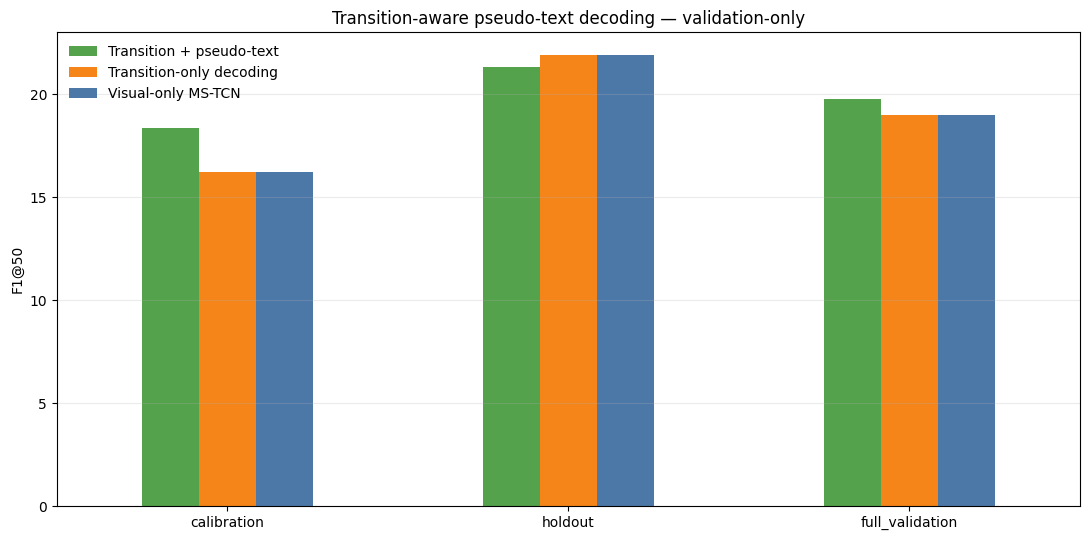

Sync final outputs to Drive:   0%|          | 0/126 [00:00<?, ?it/s]

Saved local summary: /content/nb29_runtime/outputs/final_summary.json
Persistent output copy: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/29_transition_aware_pseudotext_decoding

FINAL RECOMMENDATION: Keep the original visual-only decoding and report this validation follow-up.


In [11]:
comparison_path = OUT_ROOT / "validation_decoder_comparison.csv"
decision_path = OUT_ROOT / "validation_decision.json"
summary_path = OUT_ROOT / "final_summary.json"
table_path = ARTIFACT_ROOT / "transition_decoder_validation_table.md"
figure_path = ARTIFACT_ROOT / "transition_decoder_f1_at_50.png"

comparison_df.to_csv(comparison_path, index=False)
decision_path.write_text(json.dumps(decision, indent=2), encoding="utf-8")

for index, sequence_id in enumerate(val_ids):
    prediction_labels = [
        id_to_label[int(class_id)] for class_id in selected_predictions[index]
    ]
    (PREDICTION_ROOT / f"{sequence_id}.txt").write_text(
        "\n".join(prediction_labels) + "\n", encoding="utf-8"
    )

presentation_table = comparison_df[
    ["split", "method", "acc", "edit", "f1@10", "f1@25", "f1@50", "f1@50_gain_vs_visual"]
].copy()
for column in ["acc", "edit", "f1@10", "f1@25", "f1@50", "f1@50_gain_vs_visual"]:
    presentation_table[column] = presentation_table[column].map(
        lambda value: f"{value:.2f}"
    )
table_path.write_text(presentation_table.to_markdown(index=False), encoding="utf-8")

plot_df = comparison_df.pivot(
    index="split", columns="method", values="f1@50"
).loc[["calibration", "holdout", "full_validation"]]
ax = plot_df.plot(
    kind="bar",
    figsize=(11, 5.5),
    color=["#54A24B", "#F58518", "#4C78A8"],
)
ax.set_ylabel("F1@50")
ax.set_xlabel("")
ax.set_title("Transition-aware pseudo-text decoding — validation-only")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

final_summary = {
    "status": "completed",
    "task": "Assembly101 transition-aware pseudo-text decoding",
    "primary_metric": "F1@50",
    "data": {
        "training_sequences_for_transition_prior": len(train_ids),
        "validation_sequences": len(val_ids),
        "calibration_sequences": len(calibration_indices),
        "holdout_sequences": len(holdout_indices),
        "test_accessed": False,
    },
    "sources": {
        "notebook28_cache": str(NOTEBOOK28_CACHE_DRIVE),
        "notebook28_summary": str(NOTEBOOK28_SUMMARY_DRIVE),
        "training_ground_truth": str(GT_DIR_DRIVE),
    },
    "transition_prior": transition_diagnostics,
    "baseline_reproduction": {
        "expected_f1@50": BASELINE_EXPECTED_F1_50,
        "tolerance": BASELINE_TOLERANCE,
        "metrics": rounded_metrics(baseline_by_split["full_validation"]),
        "passed": True,
    },
    "search": {
        "num_candidates": len(search_df),
        "selection_split": "calibration",
        "holdout_used_for_selection": False,
        "search_results": str(search_path),
    },
    "metrics": {
        method: {
            split: rounded_metrics(metrics)
            for split, metrics in split_metrics.items()
        }
        for method, split_metrics in metrics_by_method.items()
    },
    "decision": decision,
    "next_step": (
        "Freeze this decoder and evaluate test once."
        if promote_to_test
        else "Keep the original visual-only decoding and report this validation follow-up."
    ),
    "artifacts": {
        "persistent_output_root": str(DRIVE_OUT_ROOT),
        "comparison_csv": str(comparison_path),
        "decision_json": str(decision_path),
        "selected_predictions": str(PREDICTION_ROOT),
        "presentation_table": str(table_path),
        "f1_at_50_figure": str(figure_path),
    },
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
summary_path.write_text(json.dumps(final_summary, indent=2), encoding="utf-8")

output_files = [path for path in OUT_ROOT.rglob("*") if path.is_file()]
for local_path in tqdm(output_files, desc="Sync final outputs to Drive"):
    copy_with_retry(
        local_path,
        DRIVE_OUT_ROOT / local_path.relative_to(OUT_ROOT),
        overwrite=True,
    )

print("Saved local summary:", summary_path)
print("Persistent output copy:", DRIVE_OUT_ROOT)
print("\nFINAL RECOMMENDATION:", final_summary["next_step"])


## Interpretation

- A positive result is credible only if the frozen decoder improves both calibration and holdout, while preserving F1@25 and Edit.
- If `text_alpha = 0`, any gain comes from train-derived transition decoding rather than pseudo-text.
- If `text_alpha > 0`, the selected decoder uses both the transition prior and Qwen pseudo-text residual.
- If `promote_to_test = false`, do not enlarge the validation search again. The next meaningful change would be a stronger VLM or a visual-top-k-conditioned VLM prompt.
